# Exploracion del conjunto de datos 
*Hourly Energy Consumption*

---

In [10]:
%load_ext autoreload
%autoreload 2

from src.data_loader import list_region_files, load_region, load_regions_dict, load_all_regions

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:

regiones = load_regions_dict()   # {region: DataFrame}, para revisar una por una
df = load_all_regions()          
print(len(regiones), "regiones cargadas")
df.head()

12 regiones cargadas


,Datetime,MW,region
0,2004-10-01 01:00:00,12379.0,AEP
1,2004-10-01 02:00:00,11935.0,AEP
2,2004-10-01 03:00:00,11692.0,AEP
3,2004-10-01 04:00:00,11597.0,AEP
4,2004-10-01 05:00:00,11681.0,AEP


In [12]:
df.info()
df.groupby('region').size()

<class 'pandas.DataFrame'>
RangeIndex: 1090167 entries, 0 to 1090166
Data columns (total 3 columns):
 #   Column    Non-Null Count    Dtype         
---  ------    --------------    -----         
 0   Datetime  1090167 non-null  datetime64[us]
 1   MW        1090167 non-null  float64       
 2   region    1090167 non-null  str           
dtypes: datetime64[us](1), float64(1), str(1)
memory usage: 29.1 MB


region
AEP         121273
COMED        66497
DAYTON      121275
DEOK         57739
DOM         116189
DUQ         119068
EKPC         45334
FE           62874
NI           58450
PJME        145366
PJMW        143206
PJM_Load     32896
dtype: int64

In [13]:
resumen = []
faltantes_por_region = {}

for nombre, d in regiones.items():
    completo = pd.date_range(d['Datetime'].min(), d['Datetime'].max(), freq='h')
    unicas = pd.DatetimeIndex(d['Datetime'].unique())
    faltan = completo.difference(unicas)
    faltantes_por_region[nombre] = faltan

    resumen.append({
        'region': nombre,
        'fecha_inicial': d['Datetime'].min(),
        'fecha_final': d['Datetime'].max(),
        'filas': len(d),
        'nulos': int(d['MW'].isnull().sum()),
        'duplicados': int(d.duplicated('Datetime').sum()),
        'horas_faltantes': len(faltan),
        'cobertura_%': round(len(unicas) / len(completo) * 100, 2),
        'ceros_o_negativos': int((d['MW'] <= 0).sum()),
    })

resumen = pd.DataFrame(resumen).set_index('region')
resumen

,fecha_inicial,fecha_final,filas,nulos,duplicados,horas_faltantes,cobertura_%,ceros_o_negativos
region,,,,,,,,
AEP,2004-10-01 01:00:00,2018-08-03,121273,0,4,27,99.98,0
COMED,2011-01-01 01:00:00,2018-08-03,66497,0,4,11,99.98,0
DAYTON,2004-10-01 01:00:00,2018-08-03,121275,0,4,25,99.98,0
DEOK,2012-01-01 01:00:00,2018-08-03,57739,0,4,9,99.98,0
DOM,2005-05-01 01:00:00,2018-08-03,116189,0,4,23,99.98,0
DUQ,2005-01-01 01:00:00,2018-08-03,119068,0,4,24,99.98,0
EKPC,2013-06-01 01:00:00,2018-08-03,45334,0,4,6,99.99,0
FE,2011-06-01 01:00:00,2018-08-03,62874,0,4,10,99.98,1
NI,2004-05-01 01:00:00,2011-01-01,58450,0,0,14,99.98,0


In [14]:
inicio_comun = resumen['fecha_inicial'].max()
fin_comun = resumen['fecha_final'].min()
print("Inicio común:", inicio_comun)
print("Fin común:   ", fin_comun)
print("¿Hay solape entre todas?", inicio_comun < fin_comun)

Inicio común: 2013-06-01 01:00:00
Fin común:    2002-01-01 00:00:00
¿Hay solape entre todas? False


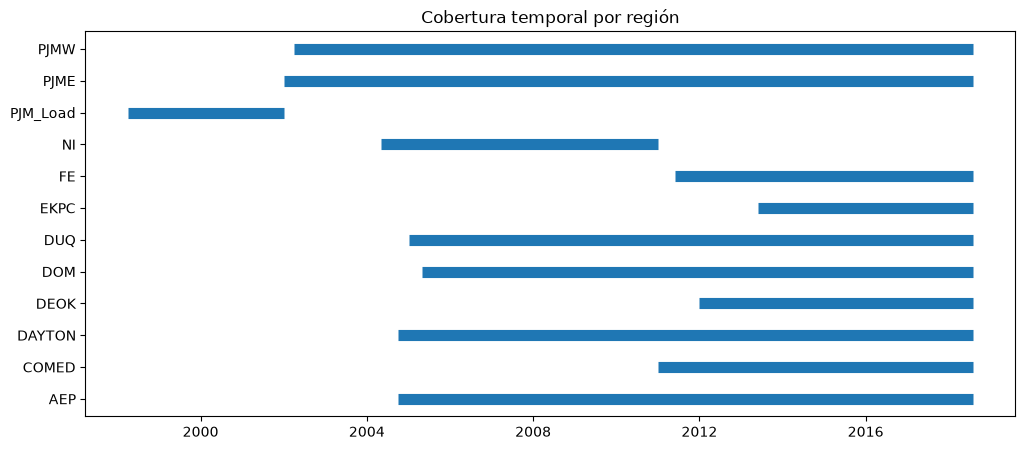

In [15]:
fig, ax = plt.subplots(figsize=(12, 5))
for i, (nombre, r) in enumerate(resumen.iterrows()):
    ax.hlines(i, r['fecha_inicial'], r['fecha_final'], linewidth=8)
ax.set_yticks(range(len(resumen)))
ax.set_yticklabels(resumen.index)
ax.set_title('Cobertura temporal por región')
plt.show()

In [16]:
for nombre, d in regiones.items():
    dups = d[d.duplicated('Datetime', keep=False)]
    if dups.empty:
        continue
    print(f"\n{nombre}: {dups['Datetime'].nunique()} fechas duplicadas")
    print(dups['Datetime'].dt.month.value_counts().sort_index().to_dict())


AEP: 4 fechas duplicadas
{11: 8}

COMED: 4 fechas duplicadas
{11: 8}

DAYTON: 4 fechas duplicadas
{11: 8}

DEOK: 4 fechas duplicadas
{11: 8}

DOM: 4 fechas duplicadas
{11: 8}

DUQ: 4 fechas duplicadas
{11: 8}

EKPC: 4 fechas duplicadas
{11: 8}

FE: 4 fechas duplicadas
{11: 8}

PJME: 4 fechas duplicadas
{11: 8}

PJMW: 4 fechas duplicadas
{11: 8}


In [17]:
d = regiones['AEP']   # cambia por la región que quieras revisar
dups = d[d.duplicated('Datetime', keep=False)]
detalle = dups.groupby('Datetime')['MW'].agg(['count', 'nunique', 'min', 'max'])
detalle.head(10)

,count,nunique,min,max
Datetime,,,,
2014-11-02 02:00:00,2,2,12994.0,13190.0
2015-11-01 02:00:00,2,2,10542.0,10785.0
2016-11-06 02:00:00,2,2,10964.0,11008.0
2017-11-05 02:00:00,2,2,10446.0,10596.0


In [18]:
faltantes_anio = pd.DataFrame({
    n: pd.Series(f.year).value_counts() for n, f in faltantes_por_region.items()
}).fillna(0).astype(int).sort_index()

faltantes_anio

,AEP,COMED,DAYTON,DEOK,DOM,DUQ,EKPC,FE,NI,PJM_Load,PJME,PJMW
1998,0,0,0,0,0,0,0,0,0,2,0,0
1999,0,0,0,0,0,0,0,0,0,2,0,0
2000,0,0,0,0,0,0,0,0,0,2,0,0
2001,0,0,0,0,0,0,0,0,0,2,0,0
2002,0,0,0,0,0,0,0,0,0,0,2,2
2003,0,0,0,0,0,0,0,0,0,0,2,2
2004,1,0,1,0,0,0,0,0,1,0,2,2
2005,2,0,2,0,1,2,0,0,2,0,2,2
2006,2,0,2,0,2,2,0,0,2,0,2,2
2007,2,0,2,0,2,2,0,0,2,0,2,2


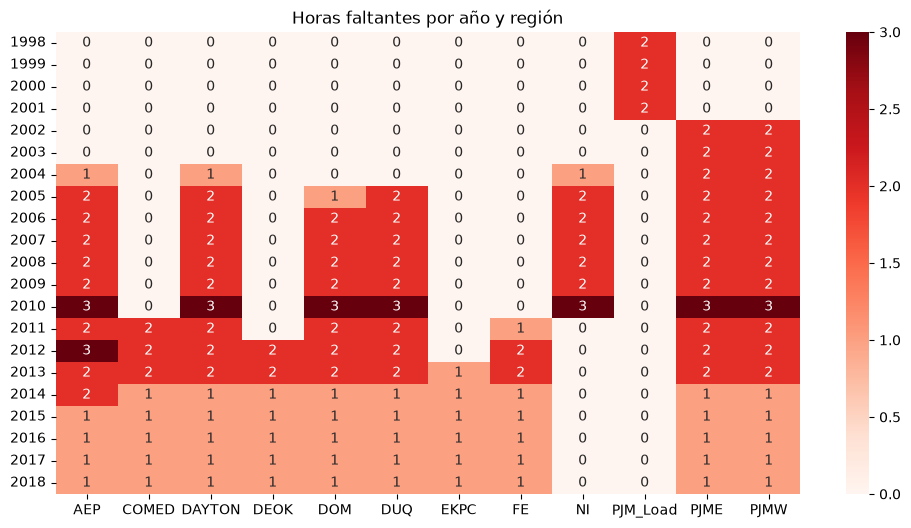

In [19]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(faltantes_anio, annot=True, fmt='d', cmap='Reds', ax=ax)
ax.set_title('Horas faltantes por año y región')
plt.show()

In [20]:
df.groupby('region')['MW'].describe().round(0)

,count,mean,std,min,25%,50%,75%,max
region,,,,,,,,
AEP,121273.0,15500.0,2591.0,9581.0,13630.0,15310.0,17200.0,25695.0
COMED,66497.0,11420.0,2304.0,7237.0,9780.0,11152.0,12510.0,23753.0
DAYTON,121275.0,2038.0,393.0,982.0,1749.0,2009.0,2279.0,3746.0
DEOK,57739.0,3105.0,600.0,907.0,2687.0,3013.0,3449.0,5445.0
DOM,116189.0,10949.0,2414.0,1253.0,9322.0,10501.0,12378.0,21651.0
DUQ,119068.0,1659.0,302.0,1014.0,1444.0,1630.0,1819.0,3054.0
EKPC,45334.0,1464.0,379.0,514.0,1185.0,1386.0,1699.0,3490.0
FE,62874.0,7792.0,1331.0,0.0,6807.0,7700.0,8556.0,14032.0
NI,58450.0,11702.0,2371.0,7003.0,9954.0,11521.0,12897.0,23631.0


In [21]:
def n_atipicos(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return int(((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum())

df.groupby('region')['MW'].apply(n_atipicos)

region
AEP          667
COMED       2388
DAYTON      1535
DEOK        1200
DOM         2106
DUQ         3391
EKPC         732
FE          1184
NI          1816
PJME        3455
PJMW         703
PJM_Load     567
Name: MW, dtype: int64

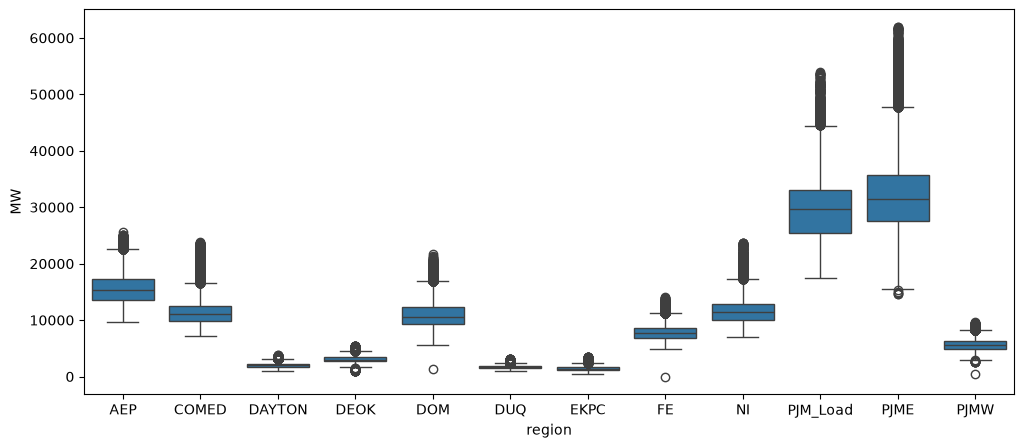

In [22]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=df, x='region', y='MW', ax=ax)
plt.show()

In [23]:
df['hora'] = df['Datetime'].dt.hour
df['mes'] = df['Datetime'].dt.month
df['dia_semana'] = df['Datetime'].dt.dayofweek

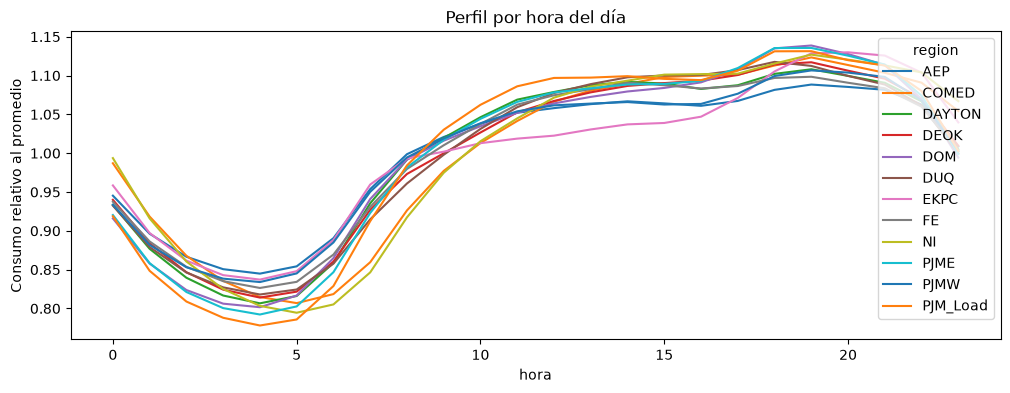

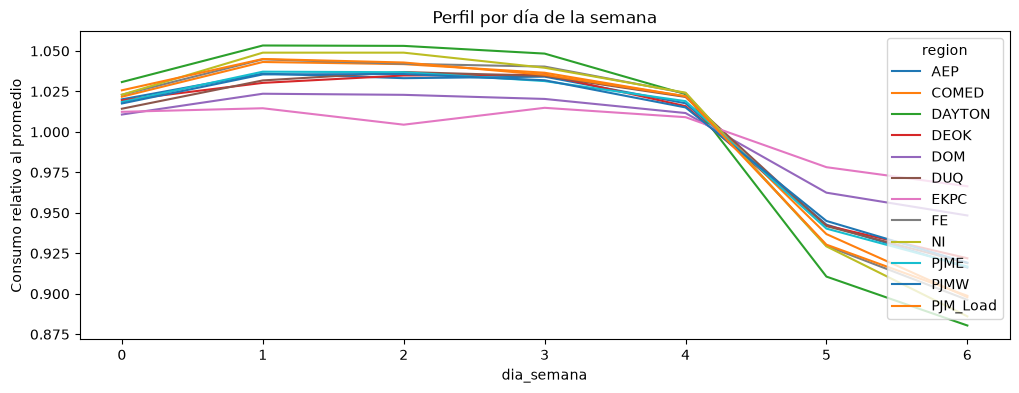

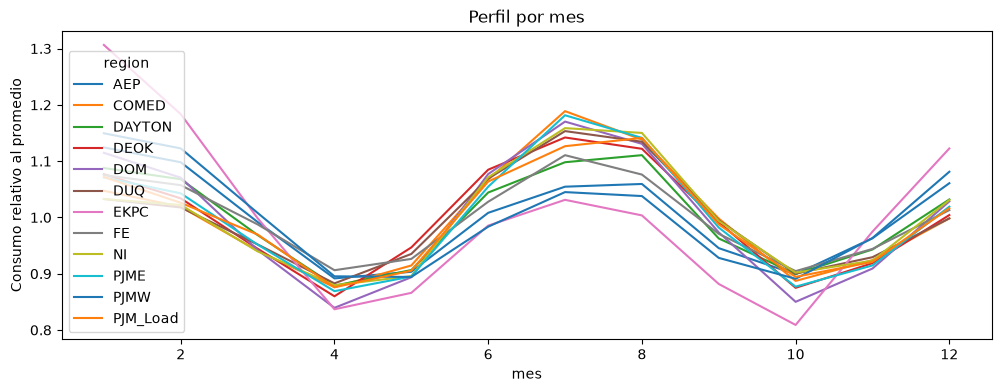

In [24]:
for col, titulo in [('hora', 'Perfil por hora del día'),
                    ('dia_semana', 'Perfil por día de la semana'),
                    ('mes', 'Perfil por mes')]:
    perfil = df.groupby(['region', col])['MW'].mean().unstack(0)
    (perfil / perfil.mean()).plot(figsize=(12, 4), title=titulo)
    plt.ylabel('Consumo relativo al promedio')
    plt.show()